In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Optional
from itertools import product

from utils import SECTORS, DR_PRICES, NG_PRICES, get_dataframe, get_scenario_name

In [32]:
# User defined variables
METHOD = "static" # "static" | "dynamic"
REGION = "new_england" # "caiso" | "new_england" | "caiso_cc"

In [33]:
# Path handling (DO NOT CHANGE)
FIGURES_BASE = Path("..","figures","heating_cap")

In [34]:
def get_capacities(region: str, scenario: str, sector: Optional[str] = None, dr_price: Optional[str] = None, method: Optional[str] = None) -> pd.Series:
    scenario = get_scenario_name(scenario=scenario, sector=sector, dr_price=dr_price)
    df = get_dataframe(region=region, method=method, scenario=scenario, sector=sector, dr_price=dr_price, result="capacity")
    cols = {"Service Gas Furnace":"Gas Furnace", "Service Air Source Heat Pump":"Air Source Heat Pump", "Service Ground Source Heat Pump":"Ground Source Heat Pump", "Service Oil Furnace":"Oil Furnace", "Service Electrical Furnace":"Electric Furnace"}
    # cols = {"Service Gas Furnace":"Gas Furnace", "Service Oil Furnace":"Oil Furnace", "Service Electrical Furnace":"Electric Furnace"}
    return df.loc[cols.keys()][["p_nom_opt"]].rename(index=cols).rename(columns={"p_nom_opt":scenario})

In [35]:
get_capacities(region=REGION, scenario="mgas", sector="et", dr_price="vlow", method=METHOD)

,et-vlow-mgas
Gas Furnace,140977.784499
Air Source Heat Pump,15875.431454
Ground Source Heat Pump,2655.762581
Oil Furnace,99069.944667
Electric Furnace,16272.441451


In [36]:
def get_data() -> dict[str,pd.DataFrame]:
    data = {}
    for ng_price in NG_PRICES:
        dfs = []
        dfs.append(get_capacities(region=REGION, scenario=ng_price))
        for sector, price in product(SECTORS, DR_PRICES):
            df = get_capacities(region=REGION, scenario=ng_price, sector=sector, dr_price=price, method=METHOD)
            dfs.append(df)
        data[ng_price] = pd.concat(dfs, axis=1)
    return data

In [37]:
def plot_bar(data: dict[str, pd.DataFrame], scenario: str, ax: Optional[plt.Axes] = None):

    title_map = {
        "lgas":"Low Natural Gas Cost",
        "mgas":"Medium Natural Gas Cost",
        "hgas":"High Natural Gas Cost",
    }

    df = data[scenario]
    cols = {
        f"{scenario}":"Base",
        f"e-vlow-{scenario}":"e-vlow", f"t-vlow-{scenario}":"t-vlow", f"et-vlow-{scenario}":"et-vlow",
        f"e-low-{scenario}":"e-low", f"t-low-{scenario}":"t-low", f"et-low-{scenario}":"et-low",
        f"e-mid-{scenario}":"e-mid", f"t-mid-{scenario}":"t-mid", f"et-mid-{scenario}":"et-mid",
        f"e-high-{scenario}":"e-high", f"t-high-{scenario}":"t-high", f"et-high-{scenario}":"et-high"
    }

    df = df[cols.keys()].rename(columns=cols).T

    # Create the plot
    if not ax:
        fig, ax = plt.subplots(figsize=(12, 8))
    else:
        fig = ax.get_figure()
    df.plot(kind="bar", ax=ax, width=0.6)

    # Vertical lines
    # Groups are at integer positions 0 to 12.
    # mgas is at 0. Line after it -> 0.5
    # vlow are at 1, 2, 3. Line after -> 3.5
    # low are at 4, 5, 6. Line after -> 6.5
    # mid are at 7, 8, 9. Line after -> 9.5
    # high are at 10, 11, 12.

    lines = [0.5, 3.5, 6.5, 9.5]
    for x in lines:
        ax.axvline(x=x, color="black", linestyle="--", linewidth=1.5)

    ax.set_title(f"{title_map[scenario]}", fontsize=14)
    ax.set_ylabel("Capacity (MW)", fontsize=14)
    ax.tick_params(axis="both", labelsize=12)
    ax.tick_params(axis="x", rotation=45)
    ax.legend().remove()

    return fig, ax

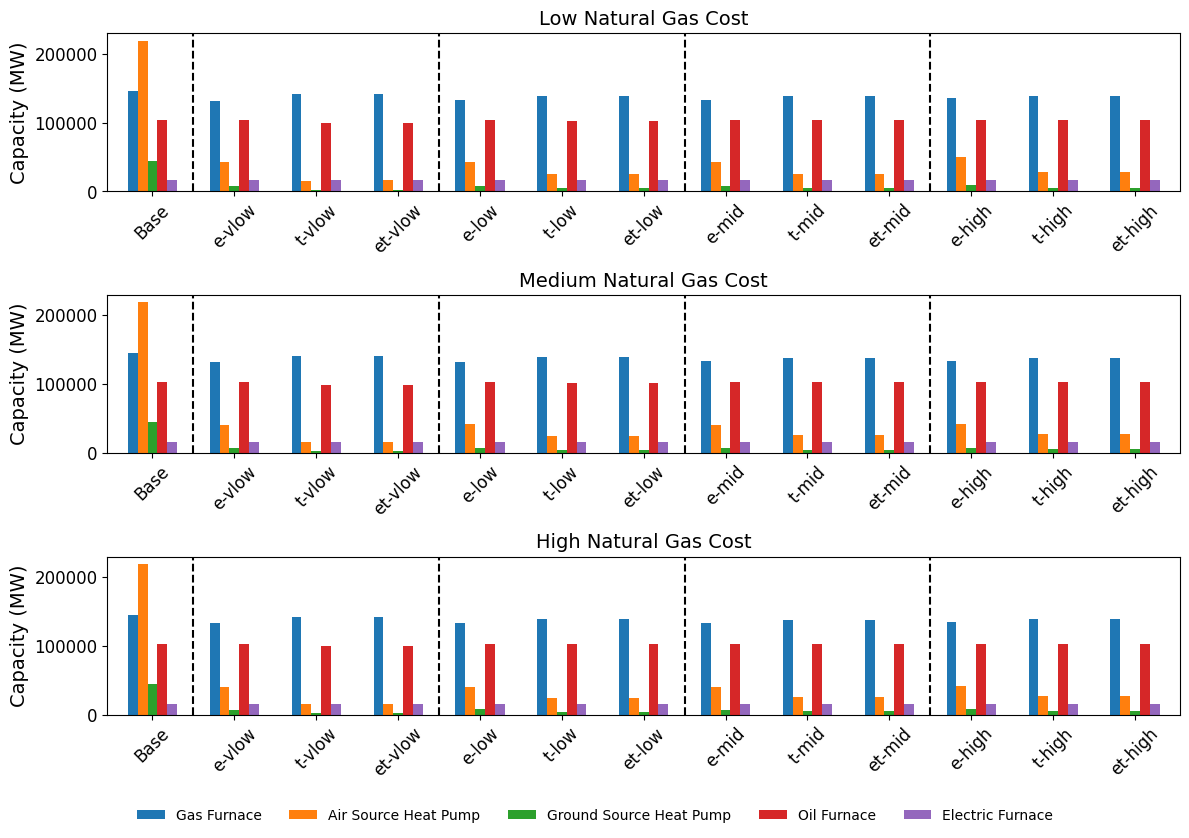

In [38]:
data = get_data()

fig, axs = plt.subplots(figsize=(12, 8), ncols=1, nrows=len(NG_PRICES))

for i,scenario in enumerate(NG_PRICES):
    plot_bar(data, scenario, ax=axs[i])
    
handles, labels = axs[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=len(labels),
    frameon=False,
    bbox_to_anchor=(0.5, -0.05) 
)

fig.tight_layout()

save_f = Path(FIGURES_BASE, f"{REGION}.png")
save_f.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(save_f, dpi=300, bbox_inches="tight")